In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models

/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models


## Imports

In [ ]:
import os
import sys
import torch

from tqdm.auto import trange
from torch.optim import Adam
from torch.utils.data import DataLoader

sys.path.append(os.path.abspath("./"))

import src.diffusion_process as dfp

from src.ou_schedules import make_ou_process_functions
from src.diffusion_utilities import plot_image_grid
from src.class_conditional import (
    ConditionalColorMNISTDataset,
    ConditionalScoreNet,
    conditional_loss_function,
    COLOR_NAME_TO_ID,
)

## Basic configuration

In [ ]:
if torch.cuda.is_available():
    device_str = "cuda"
elif torch.backends.mps.is_available():
    device_str = "mps"
else:
    device_str = "cpu"

device = torch.device(device_str)
print("Device:", device)

torch.manual_seed(123)

Device: cuda


## Load dataset

In [ ]:
data_train = ConditionalColorMNISTDataset(
    root="./data",
    train=True,
    image_size=32,
    download=True,
)

data_loader = DataLoader(
    data_train,
    batch_size=64,
    shuffle=True,
    num_workers=2,
)

print("Number of images:", len(data_train))
print("Available colors:", list(COLOR_NAME_TO_ID.keys()))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.65MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 137kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.09MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.3MB/s]

Number of images: 60000
Available colors: ['red', 'green', 'blue', 'yellow', 'cyan', 'magenta', 'orange', 'purple']


## Dataset visualization

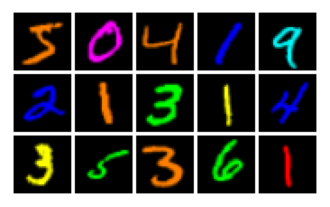

In [ ]:
images = [data_train[i][0] for i in range(15)]

_ = plot_image_grid(
    images=images,
    figsize=(4, 4),
    n_rows=3,
    n_cols=5,
    cmap=None,
)

## Proceso OU cosine + modelo

In [ ]:
schedule_name = "cosine"
sched = make_ou_process_functions(schedule_name)

diffusion_process = dfp.GaussianDiffusionProcess(
    drift_coefficient=sched["drift_coefficient"],
    diffusion_coefficient=sched["diffusion_coefficient"],
    mu_t=sched["mu_t"],
    sigma_t=sched["sigma_t"],
)

score_model = ConditionalScoreNet(
    marginal_prob_std=sched["sigma_t"],
    in_channels=3,
    out_channels=3,
    n_digits=10,
    n_colors=len(COLOR_NAME_TO_ID),
).to(device)

## Train

In [ ]:
learning_rate = 1.0e-3
optimizer = Adam(score_model.parameters(), lr=learning_rate)

n_epochs = 500
tqdm_epoch = trange(n_epochs)

for epoch in tqdm_epoch:
    avg_loss = 0.0
    num_items = 0

    for x, digit_labels, color_labels in data_loader:
        x = x.to(device)
        digit_labels = digit_labels.to(device)
        color_labels = color_labels.to(device)

        loss = conditional_loss_function(
            diffusion_process=diffusion_process,
            score_model=score_model,
            x_0=x,
            digit_labels=digit_labels,
            color_labels=color_labels,
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    tqdm_epoch.set_description(
        "Average Loss: {:.5f}".format(avg_loss / num_items)
    )

    if (epoch + 1) in [10, 20, 50, 100, 200, 500]:
        path = f"./{checkpoint_dir}/checkpoint_conditional_ou_cosine_epoch{epoch+1}.pth"
        torch.save(score_model.state_dict(), path)
        print(f"Saved: {path}")

  0%|          | 0/500 [00:00<?, ?it/s]

Saved: ../checkpoints/conditional_cmnist_ou_cosine/checkpoint_conditional_ou_cosine_epoch10.pth
Saved: ../checkpoints/conditional_cmnist_ou_cosine/checkpoint_conditional_ou_cosine_epoch20.pth
Saved: ../checkpoints/conditional_cmnist_ou_cosine/checkpoint_conditional_ou_cosine_epoch50.pth
Saved: ../checkpoints/conditional_cmnist_ou_cosine/checkpoint_conditional_ou_cosine_epoch100.pth
Saved: ../checkpoints/conditional_cmnist_ou_cosine/checkpoint_conditional_ou_cosine_epoch200.pth
Saved: ../checkpoints/conditional_cmnist_ou_cosine/checkpoint_conditional_ou_cosine_epoch500.pth
